In [6]:
import pandas as pd
import numpy as np

column_names = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
]

# Add sensor names
for i in range(1, 22):
    column_names.append(f"sensor_{i}")

df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

df.head()
df.shape


(20631, 26)

In [2]:
df[["sensor_5", "sensor_16", "sensor_18"]].nunique()

sensor_5     1
sensor_16    1
sensor_18    1
dtype: int64

In [7]:
max_cycles = df.groupby("engine_id")["cycle"].max()
max_cycles.head()
df["max_cycle"] = df.groupby("engine_id")["cycle"].transform("max")

df.head(20)
df["RUL"] = df["max_cycle"] - df["cycle"]

df.head()
df[df["engine_id"] == 1][["cycle", "RUL"]].tail(10)
engine_1 = df[df["engine_id"] == 1]

engine_1.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


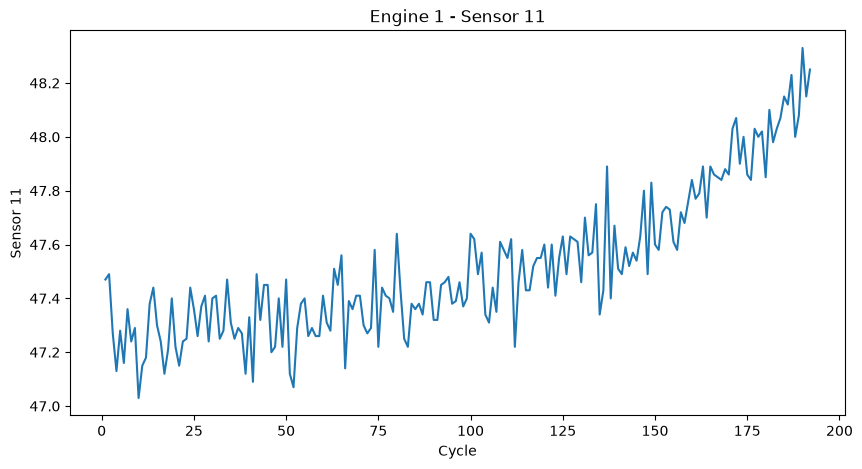

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(engine_1["cycle"], engine_1["sensor_11"])

plt.title("Engine 1 - Sensor 11")
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")

plt.show()

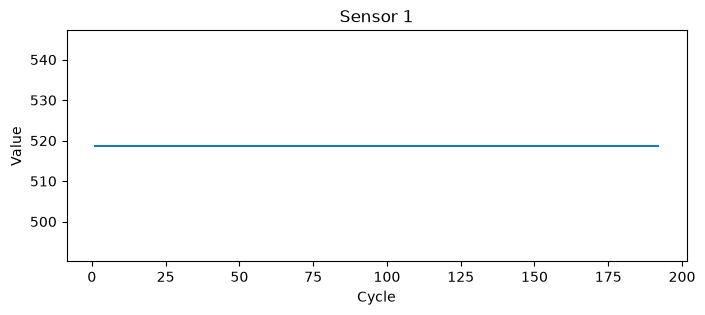

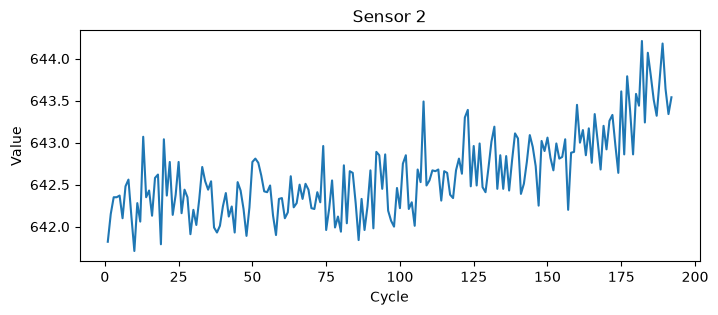

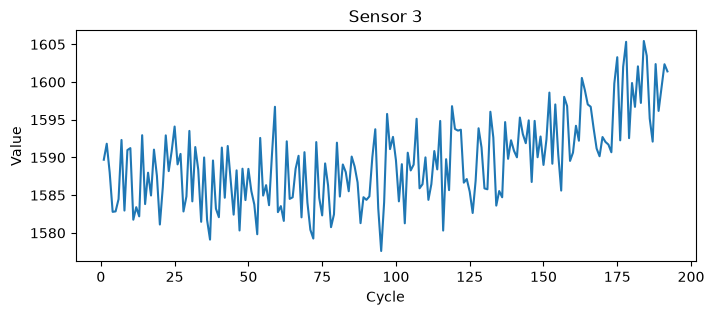

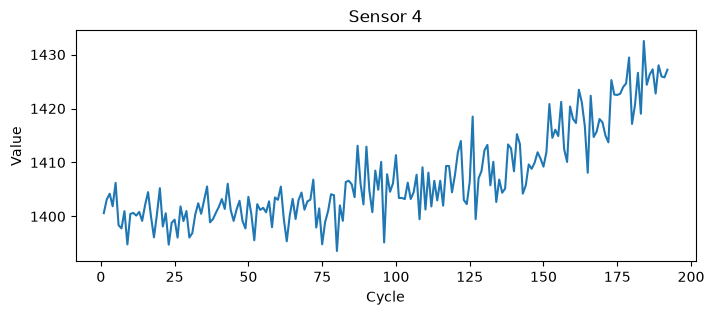

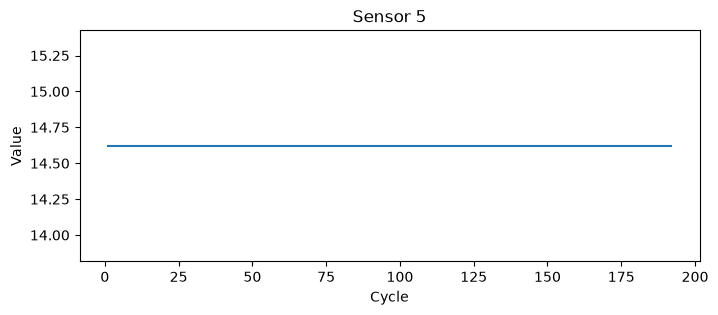

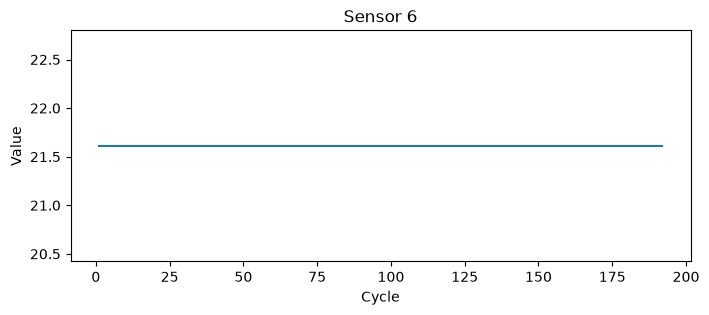

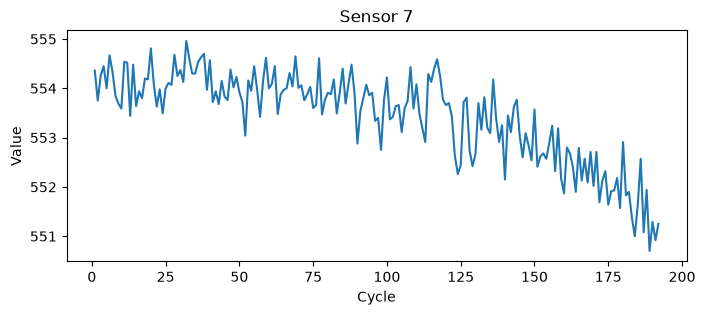

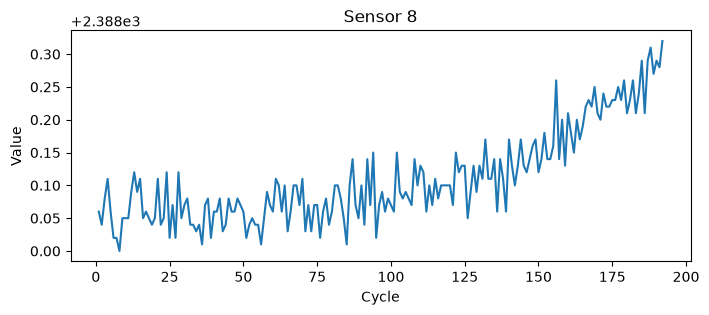

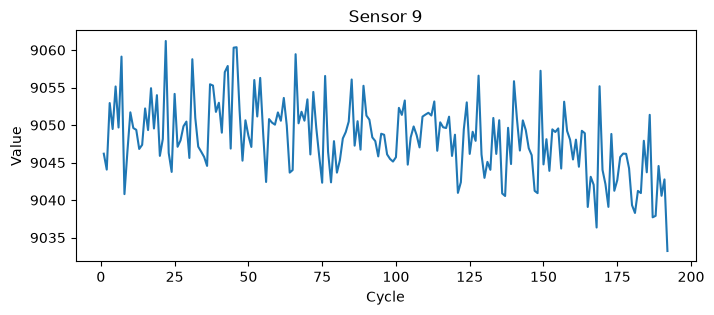

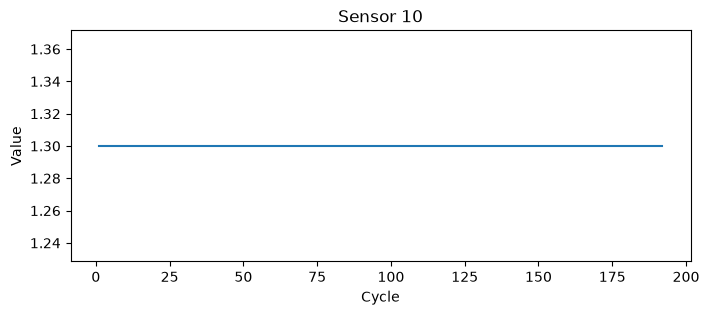

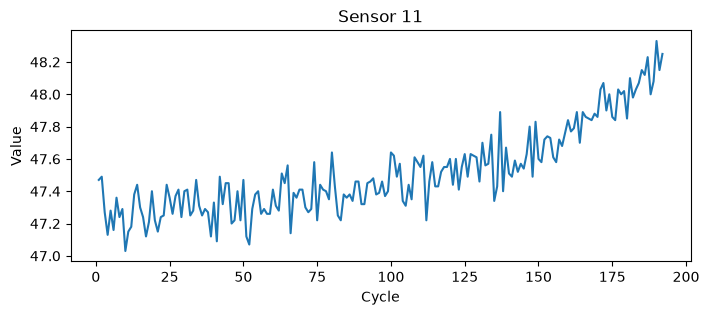

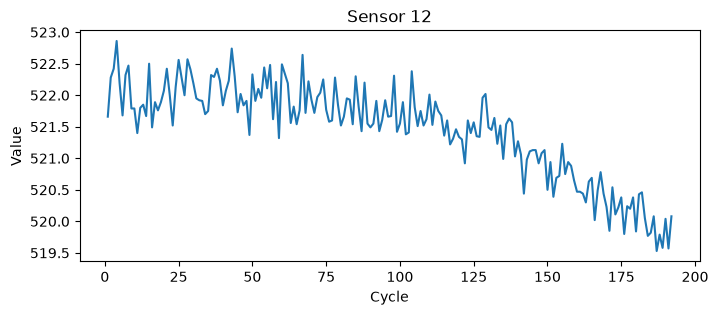

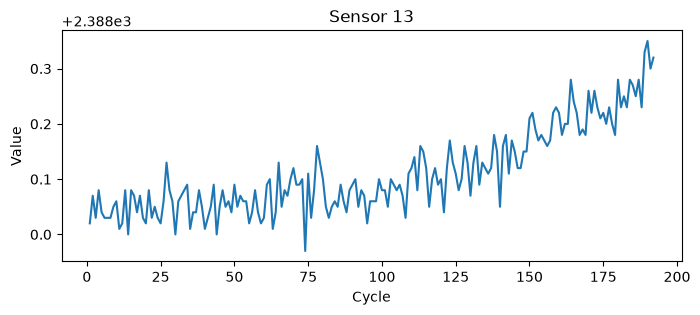

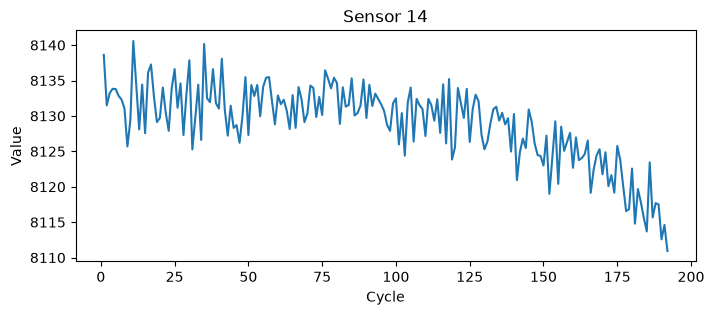

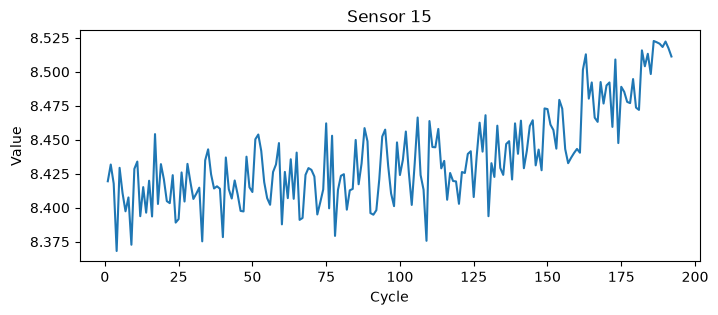

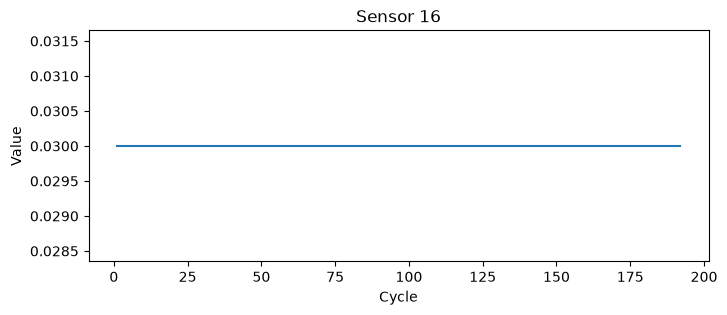

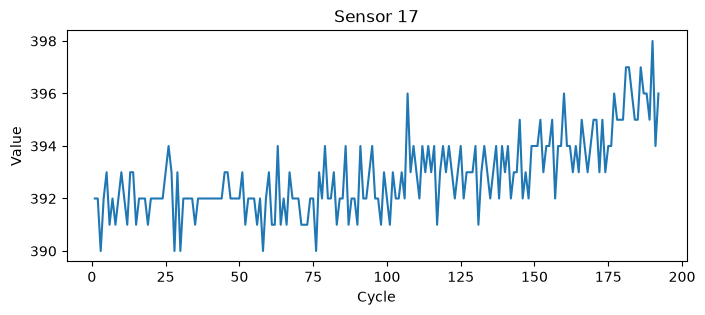

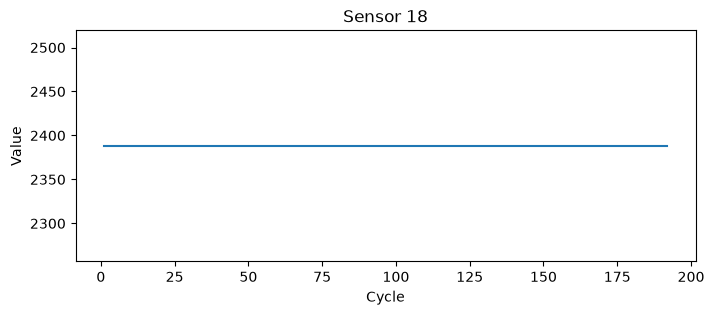

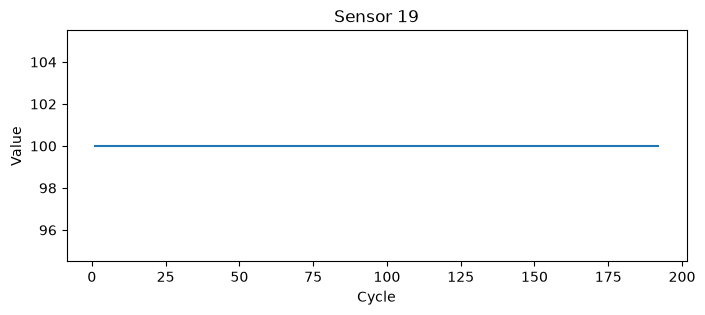

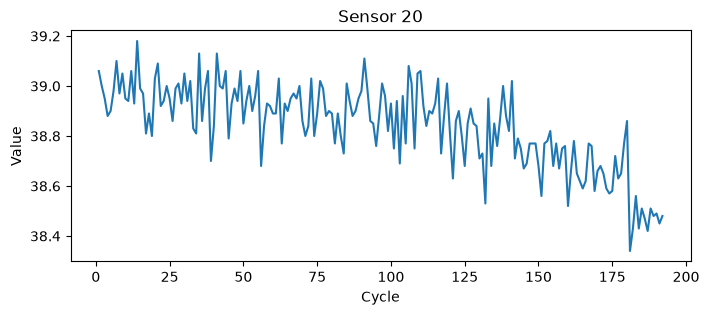

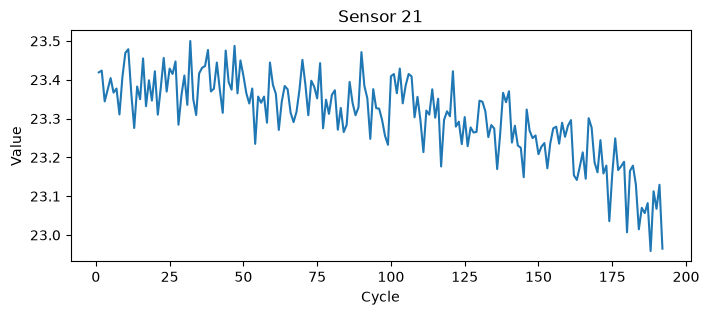

In [6]:
for i in range(1, 22):
    plt.figure(figsize=(8,3))
    plt.plot(engine_1["cycle"], engine_1[f"sensor_{i}"])
    plt.title(f"Sensor {i}")
    plt.xlabel("Cycle")
    plt.ylabel("Value")
    plt.show()

In [8]:
correlation = df.corr(numeric_only=True)["RUL"].sort_values()

print(correlation)

cycle          -0.736241
sensor_11      -0.696228
sensor_4       -0.678948
sensor_15      -0.642667
sensor_2       -0.606484
sensor_17      -0.606154
sensor_3       -0.584520
sensor_8       -0.563968
sensor_13      -0.562569
sensor_9       -0.390102
sensor_14      -0.306769
sensor_6       -0.128348
op_setting_1   -0.003198
op_setting_2   -0.001948
engine_id       0.078753
max_cycle       0.363152
sensor_20       0.629428
sensor_21       0.635662
sensor_7        0.657223
sensor_12       0.671983
RUL             1.000000
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: RUL, dtype: float64


In [7]:
df[["sensor_5", "sensor_16", "sensor_18"]].nunique()

sensor_5     1
sensor_16    1
sensor_18    1
dtype: int64

In [8]:
df = df.drop(columns=["sensor_5", "sensor_16", "sensor_18"])

In [10]:
df.shape


(20631, 25)

In [9]:
from sklearn.model_selection import train_test_split

engine_ids = df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)


train_df = df[df["engine_id"].isin(train_engines)].copy()

val_df = df[df["engine_id"].isin(val_engines)].copy()
print(train_df["engine_id"].nunique())
print(val_df["engine_id"].nunique())

80
20


In [8]:
df.groupby("engine_id")["cycle"].max()

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [10]:
feature_columns = [
    col for col in train_df.columns
    if col not in ["engine_id", "max_cycle", "RUL"]
]

X_train = train_df[feature_columns]
y_train = train_df["RUL"]

X_val = val_df[feature_columns]
y_val = val_df["RUL"]

print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)
print(feature_columns)
print(len(feature_columns))

(16561, 25)
(16561,)
(4070, 25)
(4070,)
['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
25


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)

In [19]:
print(y_pred[:10])

[211.875 207.575 205.295 230.885 211.36  214.715 202.145 205.61  207.525
 205.165]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 23.950797297297296
RMSE: 31.622306334963305
R²: 0.7679976366725673


In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_val)

In [23]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2 = r2_score(y_val, xgb_pred)

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

XGBoost
MAE: 25.784183502197266
RMSE: 34.388855517290224
R²: 0.7256274223327637


In [30]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_pl

In [31]:
best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_val)

print("Best parameters:", grid_xgb.best_params_)
print("MAE:", mean_absolute_error(y_val, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, xgb_pred)))
print("R²:", r2_score(y_val, xgb_pred))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
MAE: 22.64811897277832
RMSE: 29.71600502405806
R²: 0.7951263189315796


In [32]:
errors = pd.DataFrame({
    "actual": y_val,
    "predicted": xgb_pred
})

errors["error"] = errors["predicted"] - errors["actual"]
errors["absolute_error"] = abs(errors["error"])

print(errors.sort_values("absolute_error", ascending=False).head(10))

       actual   predicted      error  absolute_error
16979     172   86.376709 -85.623291       85.623291
16982     169   84.737022 -84.262978       84.262978
16976     175   91.529816 -83.470184       83.470184
16973     178   96.015610 -81.984390       81.984390
16995     156   75.655067 -80.344933       80.344933
16969     182  102.235458 -79.764542       79.764542
16885     266  186.565674 -79.434326       79.434326
16985     166   86.571732 -79.428268       79.428268
16991     160   80.697136 -79.302864       79.302864
16980     171   91.993477 -79.006523       79.006523


In [34]:
df["RUL_capped"] = df["RUL"].clip(upper=125)
y_train_cap = train_df["RUL"].clip(upper=125)
y_val_cap = val_df["RUL"].clip(upper=125)
xgb_cap = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_cap.fit(X_train, y_train_cap)

pred_cap = xgb_cap.predict(X_val)
print("MAE:", mean_absolute_error(y_val_cap, pred_cap))
print("RMSE:", np.sqrt(mean_squared_error(y_val_cap, pred_cap)))
print("R²:", r2_score(y_val_cap, pred_cap))

MAE: 10.803292274475098
RMSE: 15.513678637045297
R²: 0.8616970777511597


In [35]:
caps = [50, 75, 100, 125, 150]

for cap in caps:
    y_train_cap = y_train.clip(upper=cap)
    y_val_cap = y_val.clip(upper=cap)

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train_cap)
    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val_cap, pred)
    rmse = np.sqrt(mean_squared_error(y_val_cap, pred))
    r2 = r2_score(y_val_cap, pred)

    print(f"Cap {cap}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

Cap 50: MAE=2.04, RMSE=4.00, R²=0.907
Cap 75: MAE=4.19, RMSE=7.17, R²=0.899
Cap 100: MAE=7.22, RMSE=11.13, R²=0.882
Cap 125: MAE=10.80, RMSE=15.51, R²=0.862
Cap 150: MAE=14.56, RMSE=19.88, R²=0.841


In [36]:
import pandas as pd

df_ts = df.copy()

sensors = ["sensor_11", "sensor_4", "sensor_15", "sensor_9"]

for sensor in sensors:
    df_ts[f"{sensor}_roll_mean"] = (
        df_ts.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )

    df_ts[f"{sensor}_roll_std"] = (
        df_ts.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    )

In [37]:
train_ts = df_ts[df_ts["engine_id"].isin(train_engines)]
val_ts = df_ts[df_ts["engine_id"].isin(val_engines)]

In [39]:
xgb_ts = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_ts.fit(X_train_ts, y_train_ts)

pred_ts = xgb_ts.predict(X_val_ts)
print("MAE:", mean_absolute_error(y_val_ts, pred_ts))
print("RMSE:", np.sqrt(mean_squared_error(y_val_ts, pred_ts)))
print("R²:", r2_score(y_val_ts, pred_ts))

MAE: 22.847623825073242
RMSE: 30.15689867339903
R²: 0.7890018224716187


In [40]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a fun

In [41]:
best_xgb = search.best_estimator_

pred = best_xgb.predict(X_val)

print("Best parameters:", search.best_params_)
print("MAE:", mean_absolute_error(y_val, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, pred)))
print("R²:", r2_score(y_val, pred))

Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
MAE: 22.772281646728516
RMSE: 29.839742245621967
R²: 0.7934166193008423


In [43]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [150, 200, 250, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.07],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

search_grouped = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=15,
    cv=gkf,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_grouped.fit(
    X_train,
    y_train,
    groups=groups
)
print("Best parameters:")
print(search_grouped.best_params_)
best_xgb_grouped = search_grouped.best_estimator_

pred_grouped = best_xgb_grouped.predict(X_val)

print("MAE:", mean_absolute_error(y_val, pred_grouped))
print("RMSE:", np.sqrt(mean_squared_error(y_val, pred_grouped)))
print("R²:", r2_score(y_val, pred_grouped))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
MAE: 22.743438720703125
RMSE: 29.81616853738924
R²: 0.7937428951263428


In [4]:
import numpy as np

sequence_length = 30

def create_sequences(data, features):
    X, y = [], []

    for engine_id, engine in data.groupby("engine_id"):
        engine = engine.sort_values("cycle")

        values = engine[features].values
        rul = engine["RUL"].values

        for i in range(sequence_length, len(engine)):
            X.append(values[i-sequence_length:i])
            y.append(rul[i])

    return np.array(X), np.array(y)

In [12]:


train_seq = df[df["engine_id"].isin(train_engines)]
val_seq = df[df["engine_id"].isin(val_engines)]

X_train_lstm, y_train_lstm = create_sequences(
    train_seq, feature_columns
)

X_val_lstm, y_val_lstm = create_sequences(
    val_seq, feature_columns
)

print(X_train_lstm.shape)
print(y_train_lstm.shape)
print(X_val_lstm.shape)
print(y_val_lstm.shape)

(14161, 30, 25)
(14161,)
(3470, 30, 25)
(3470,)


In [13]:
from sklearn.model_selection import train_test_split

# Recreate target columns
df["max_cycle"] = df.groupby("engine_id")["cycle"].transform("max")
df["RUL"] = df["max_cycle"] - df["cycle"]

# Engine-level train/validation split
engine_ids = df["engine_id"].unique()
train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

# Same feature selection used earlier
feature_columns = [
    col for col in df.columns
    if col not in ["engine_id", "max_cycle", "RUL"]
]

In [38]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
print(X_train_lstm.shape)
print(len(feature_columns))
print(feature_columns)

(14161, 30, 25)
25
['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [44]:
n_features = X_train_lstm.shape[2]

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(64, input_shape=(30, n_features)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 11213.2500 - mae: 85.9605 - val_loss: 7864.2671 - val_mae: 70.5848
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 6419.4233 - mae: 61.5146 - val_loss: 3838.6228 - val_mae: 49.9785
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 4198.7778 - mae: 51.5432 - val_loss: 3363.4734 - val_mae: 48.4796
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 4063.6182 - mae: 51.4521 - val_loss: 3364.0786 - val_mae: 48.5367
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 4066.7031 - mae: 51.4608 - val_loss: 3364.4746 - val_mae: 48.5526
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 4068.5259 - mae: 51.5030 - val_loss: 3369.5852 - val_mae: 48.6661
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 4058.4651 - mae: 51.5932 - val_loss: 3364.5737 - val_mae: 48.5560
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 4058.2549 - mae: 51.3968 - val_loss: 3364.7478 -

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

n_train, timesteps, n_features = X_train_lstm.shape
n_val = X_val_lstm.shape[0]

X_train_2d = X_train_lstm.reshape(-1, n_features)
X_val_2d = X_val_lstm.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(
    n_train, timesteps, n_features
)

X_val_scaled = scaler.transform(X_val_2d).reshape(
    n_val, timesteps, n_features
)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_scaled.shape[2]

lstm_scaled = Sequential([
    LSTM(64, input_shape=(30, n_features)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_scaled.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_scaled = lstm_scaled.fit(
    X_train_scaled,
    y_train_lstm,
    validation_data=(X_val_scaled, y_val_lstm),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 6586.8467 - mae: 58.9688 - val_loss: 1449.7511 - val_mae: 26.1599
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1504.1278 - mae: 25.8349 - val_loss: 748.8011 - val_mae: 19.8872
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1120.7085 - mae: 22.1207 - val_loss: 606.4442 - val_mae: 18.2089
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 977.0367 - mae: 20.9030 - val_loss: 575.4097 - val_mae: 16.3526
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 860.7189 - mae: 19.4419 - val_loss: 583.3445 - val_mae: 17.5196
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 763.7442 - mae: 18.4733 - val_loss: 598.8726 - val_mae: 17.2276
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 704.5615 - mae: 17.6324 - val_loss: 684.5562 - val_mae: 18.5475
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 619.8447 - mae: 16.7308 - val_loss: 658.7964 - val_mae: 17.7

In [15]:
import numpy as np

sequence_length = 30

def create_sequences(data, features):
    X, y = [], []

    for engine_id, engine in data.groupby("engine_id"):
        engine = engine.sort_values("cycle")

        values = engine[features].values
        rul = engine["RUL"].values

        for i in range(sequence_length, len(engine)):
            X.append(values[i-sequence_length:i])
            y.append(rul[i])

    return np.array(X), np.array(y)

train_seq = df[df["engine_id"].isin(train_engines)]
val_seq = df[df["engine_id"].isin(val_engines)]

X_train_lstm, y_train_lstm = create_sequences(
    train_seq, feature_columns
)

X_val_lstm, y_val_lstm = create_sequences(
    val_seq, feature_columns
)

print(X_train_lstm.shape)
print(X_val_lstm.shape)

(14161, 30, 22)
(3470, 30, 22)


In [14]:
feature_columns = [
    'cycle',
    'op_setting_1',
    'op_setting_2',
    'op_setting_3',
    'sensor_1',
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_6',
    'sensor_7',
    'sensor_8',
    'sensor_9',
    'sensor_10',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_14',
    'sensor_15',
    'sensor_17',
    'sensor_19',
    'sensor_20',
    'sensor_21'
]

In [19]:
train_seq = df[df["engine_id"].isin(train_engines)]
val_seq = df[df["engine_id"].isin(val_engines)]

X_train_lstm, y_train_lstm = create_sequences(
    train_seq, feature_columns
)

X_val_lstm, y_val_lstm = create_sequences(
    val_seq, feature_columns
)

print(X_train_lstm.shape)
print(X_val_lstm.shape)

(14161, 30, 22)
(3470, 30, 22)


In [16]:
from sklearn.preprocessing import StandardScaler

n_train, timesteps, n_features = X_train_lstm.shape
n_val = X_val_lstm.shape[0]

scaler = StandardScaler()

X_train_2d = X_train_lstm.reshape(-1, n_features)
X_val_2d = X_val_lstm.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(
    n_train, timesteps, n_features
)

X_val_scaled = scaler.transform(X_val_2d).reshape(
    n_val, timesteps, n_features
)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_stacked = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 22)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_stacked.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
history_stacked = lstm_stacked.fit(
    X_train_scaled,
    y_train_lstm,
    validation_data=(X_val_scaled, y_val_lstm),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 8083.7324 - mae: 68.1282 - val_loss: 2716.2136 - val_mae: 36.0795
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 1933.5574 - mae: 28.4415 - val_loss: 912.0511 - val_mae: 22.1012
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 1096.5814 - mae: 21.4959 - val_loss: 722.9009 - val_mae: 19.4134
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 890.0357 - mae: 19.5912 - val_loss: 842.4700 - val_mae: 20.9965
Epoch 5/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 737.5597 - mae: 18.1279 - val_loss: 884.8087 - val_mae: 21.8370
Epoch 6/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 624.9241 - mae: 16.6693 - val_loss: 886.0850 - val_mae: 20.9171
Epoch 7/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 508.1268 - mae: 15.1880 - val_loss: 951.4056 - val_mae: 21.5024
Epoch 8/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 432.8175 - mae: 14.0289 - val_loss: 868.0161 - val_mae: 20

In [31]:
lstm_pred = lstm_stacked.predict(X_val_scaled).ravel()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_val_lstm, lstm_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_lstm, lstm_pred)))
print("R²:", r2_score(y_val_lstm, lstm_pred))

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE: 19.413423538208008
RMSE: 26.88681607974901
R²: 0.7850717306137085


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

cnn_lstm = Sequential([
    Conv1D(32, kernel_size=3, activation="relu",
           input_shape=(30, 22)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

cnn_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

cnn_pred = cnn_lstm.predict(X_val_scaled).ravel()

print("MAE:", mean_absolute_error(y_val_lstm, cnn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_lstm, cnn_pred)))
print("R²:", r2_score(y_val_lstm, cnn_pred))

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MAE: 20.337846755981445
RMSE: 26.164972270686267
R²: 0.7964573502540588


In [28]:
def make_sequences(data, features, seq_len):
    X, y = [], []

    for _, engine in data.groupby("engine_id"):
        engine = engine.sort_values("cycle")
        values = engine[features].values
        rul = engine["RUL"].values

        for i in range(seq_len, len(engine)):
            X.append(values[i-seq_len:i])
            y.append(rul[i])

    return np.array(X), np.array(y)

In [36]:
X_train_20, y_train_20 = make_sequences(train_seq, feature_columns, 20)
X_val_20, y_val_20 = make_sequences(val_seq, feature_columns, 20)

print(X_train_20.shape, X_val_20.shape)

(14961, 20, 22) (3670, 20, 22)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm20 = Sequential([
    LSTM(64, input_shape=(20, n_features)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm20.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lstm20.fit(
    X_train_20_scaled,
    y_train_20,
    validation_data=(X_val_20_scaled, y_val_20),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 5915.5171 - mae: 54.9798 - val_loss: 1055.1970 - val_mae: 23.5724
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 1434.8628 - mae: 26.3686 - val_loss: 823.5156 - val_mae: 21.6490
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1236.1628 - mae: 24.4621 - val_loss: 737.7077 - val_mae: 20.4258
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1105.4944 - mae: 23.0260 - val_loss: 770.0359 - val_mae: 20.4509
Epoch 5/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1008.4105 - mae: 22.0293 - val_loss: 895.9424 - val_mae: 21.9236
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 972.9742 - mae: 21.5960 - val_loss: 833.6910 - val_mae: 21.0805
Epoch 7/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 891.0449 - mae: 20.6706 - val_loss: 843.1678 - val_mae: 20.8688
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 809.4107 - mae: 19.7481 - val_loss: 857.2828 - val_mae: 2

In [39]:
pred20 = lstm20.predict(X_val_20_scaled).ravel()

print("MAE:", mean_absolute_error(y_val_20, pred20))
print("RMSE:", np.sqrt(mean_squared_error(y_val_20, pred20)))
print("R²:", r2_score(y_val_20, pred20))

115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MAE: 20.425756454467773
RMSE: 27.160775074300048
R²: 0.7985856533050537


In [43]:
pred50 = lstm50.predict(X_val_50_scaled).ravel()

print("MAE:", mean_absolute_error(y_val_50, pred50))
print("RMSE:", np.sqrt(mean_squared_error(y_val_50, pred50)))
print("R²:", r2_score(y_val_50, pred50))

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MAE: 14.226466178894043
RMSE: 20.813453079716552
R²: 0.846045970916748


In [44]:
X_train_75, y_train_75 = make_sequences(train_seq, feature_columns, 75)
X_val_75, y_val_75 = make_sequences(val_seq, feature_columns, 75)

print(X_train_75.shape, X_val_75.shape)

(10561, 75, 22) (2570, 75, 22)


In [45]:
scaler75 = StandardScaler()

n_train, seq_len, n_features = X_train_75.shape

X_train_75_2d = X_train_75.reshape(-1, n_features)
X_val_75_2d = X_val_75.reshape(-1, n_features)

scaler75.fit(X_train_75_2d)

X_train_75_scaled = scaler75.transform(X_train_75_2d).reshape(
    n_train, seq_len, n_features
)

X_val_75_scaled = scaler75.transform(X_val_75_2d).reshape(
    X_val_75.shape[0], seq_len, n_features
)

In [47]:
pred75 = lstm75.predict(X_val_75_scaled).ravel()

print("MAE:", mean_absolute_error(y_val_75, pred75))
print("RMSE:", np.sqrt(mean_squared_error(y_val_75, pred75)))
print("R²:", r2_score(y_val_75, pred75))

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
MAE: 9.916629791259766
RMSE: 15.919590599891823
R²: 0.88566654920578


In [30]:
X_train_100, y_train_100 = make_sequences(train_seq, feature_columns, 100)
X_val_100, y_val_100 = make_sequences(val_seq, feature_columns, 100)

print(X_train_100.shape, X_val_100.shape)

(8561, 100, 22) (2070, 100, 22)


In [31]:
scaler100 = StandardScaler()

n_train, seq_len, n_features = X_train_100.shape

X_train_100_2d = X_train_100.reshape(-1, n_features)
X_val_100_2d = X_val_100.reshape(-1, n_features)

scaler100.fit(X_train_100_2d)

X_train_100_scaled = scaler100.transform(X_train_100_2d).reshape(
    n_train, seq_len, n_features
)

X_val_100_scaled = scaler100.transform(X_val_100_2d).reshape(
    X_val_100.shape[0], seq_len, n_features
)

In [32]:
lstm100 = Sequential([
    LSTM(64, input_shape=(100, n_features)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm100.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm100.fit(
    X_train_100_scaled,
    y_train_100,
    validation_data=(X_val_100_scaled, y_val_100),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 4061.1255 - mae: 45.4879 - val_loss: 881.6353 - val_mae: 19.9952
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - loss: 908.0967 - mae: 18.0161 - val_loss: 224.1687 - val_mae: 10.5043
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 486.7401 - mae: 13.5671 - val_loss: 182.2626 - val_mae: 8.3188
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 285.4790 - mae: 10.7466 - val_loss: 151.5185 - val_mae: 8.2035
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 224.8545 - mae: 9.7914 - val_loss: 153.4117 - val_mae: 7.5641
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 152.6648 - mae: 8.3568 - val_loss: 130.7325 - val_mae: 6.9356
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - loss: 136.4893 - mae: 7.8580 - val_loss: 101.1026 - val_mae: 6.1550
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 107.7112 - mae: 7.2445 - val_loss: 92.3058 - val_mae: 5.9210
Epoc

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred100 = lstm100.predict(X_val_100_scaled).ravel()

print("MAE:", mean_absolute_error(y_val_100, pred100))
print("RMSE:", np.sqrt(mean_squared_error(y_val_100, pred100)))
print("R²:", r2_score(y_val_100, pred100))

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
MAE: 5.920953273773193
RMSE: 9.60759121845825
R²: 0.9461610913276672


In [38]:
lstm100.save("../lstm100.keras")

In [41]:
import joblib

joblib.dump(scaler100, "../scaler100.pkl")

['../scaler100.pkl']

In [37]:
import os

print(os.path.exists("../lstm100.keras"))
print(os.path.exists("../scaler100.pkl"))

True
True
